## Week 5:Intro to Time Series

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
raw_spydata = pd.read_csv("data5_SPY.csv", header = 0, index_col = 0)
data = raw_spydata.copy()

In [5]:
data.index = pd.to_datetime(data.index)
data = data.asfreq('b')
data = data.ffill()
data.head()

/var/folders/c7/gjfq1y494ngg8_kz3krcbhcm0000gn/T/ipykernel_15622/319459430.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.index = pd.to_datetime(data.index)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1994-01-03,46.59375,46.65625,46.40625,46.46875,27.784529,960900.0
1994-01-04,46.53125,46.65625,46.46875,46.65625,27.896648,164300.0
1994-01-05,46.71875,46.78125,46.53125,46.75000,27.952698,710900.0
1994-01-06,46.81250,46.84375,46.68750,46.75000,27.952698,201000.0
1994-01-07,46.84375,47.06250,46.71875,47.03125,28.120859,775500.0


In [7]:
data.loc["2021"].mean()

Open         4.257463e+02
High         4.277203e+02
Low          4.236387e+02
Close        4.259510e+02
Adj Close    4.227260e+02
Volume       7.364414e+07
dtype: float64

In [9]:
data.head(3)
col = ['Adj Close', 'Volume']
data = data[col]
data.columns = ['spy_price','spy_vol']
data.head(3)

,spy_price,spy_vol
Date,,
1994-01-03,27.784529,960900.0
1994-01-04,27.896648,164300.0
1994-01-05,27.952698,710900.0


<Axes: title={'center': 'SPY price'}, xlabel='Date'>

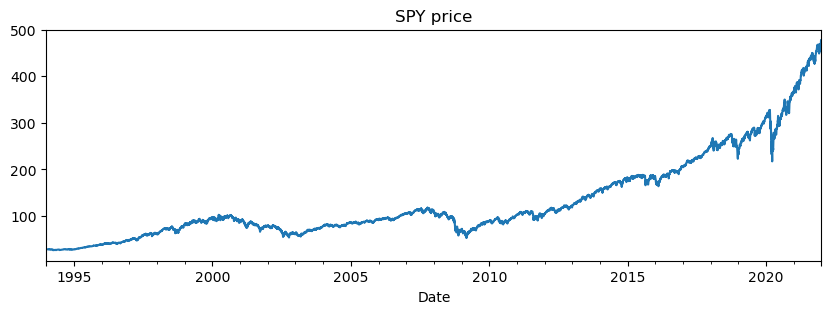

In [11]:
data.spy_price.plot(figsize = (10,3), title = "SPY price")

<Axes: title={'center': 'SPY volume'}, xlabel='Date'>

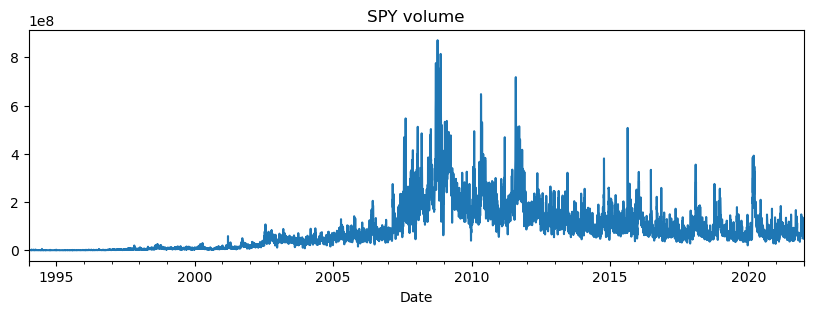

In [13]:
data.spy_vol.plot(figsize = (10,3), title = "SPY volume")

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

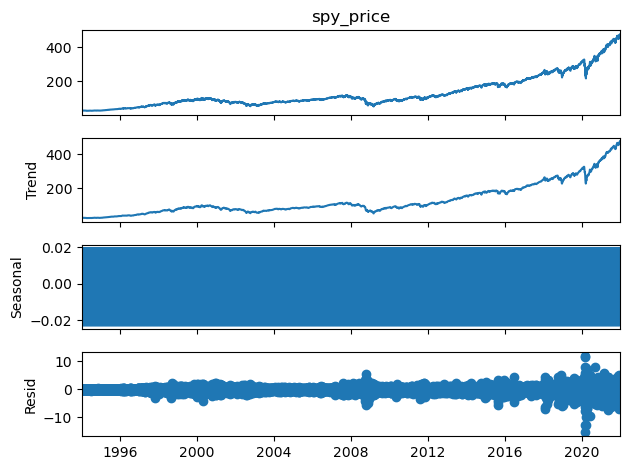

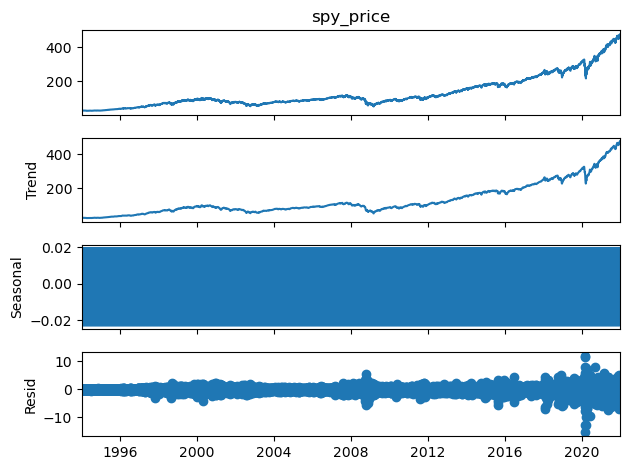

In [17]:
decomp_spy = seasonal_decompose(data.spy_price, model = "additive")
decomp_spy.plot()

/var/folders/c7/gjfq1y494ngg8_kz3krcbhcm0000gn/T/ipykernel_15622/2252025352.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  unemp.index = pd.to_datetime(unemp.index)


<Axes: title={'center': 'US unemployment rate - NSA'}, xlabel='DATE'>

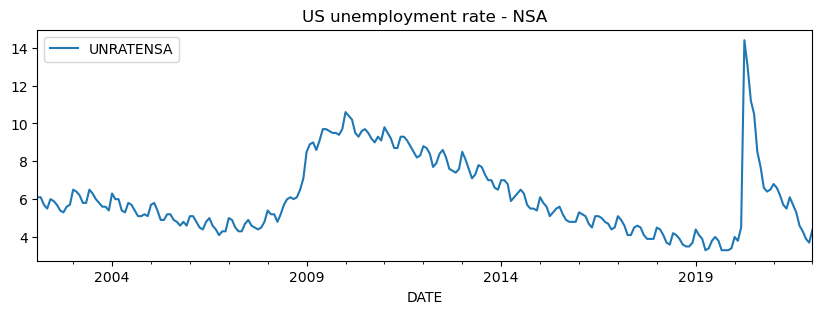

In [19]:
unemp = pd.read_csv("data5_UNRATENSA.csv", header = 0, index_col = 0)
unemp = unemp[-240:]
unemp.index = pd.to_datetime(unemp.index)
unemp.plot(figsize = (10,3), title = "US unemployment rate - NSA")

In [21]:
unemp.head(2)

,UNRATENSA
DATE,
2002-02-01,6.1
2002-03-01,6.1


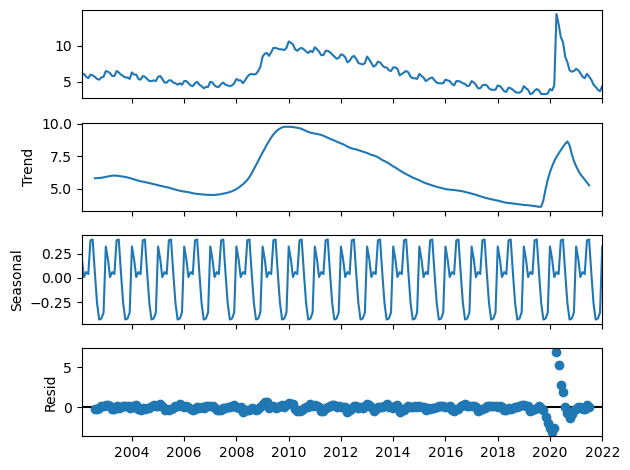

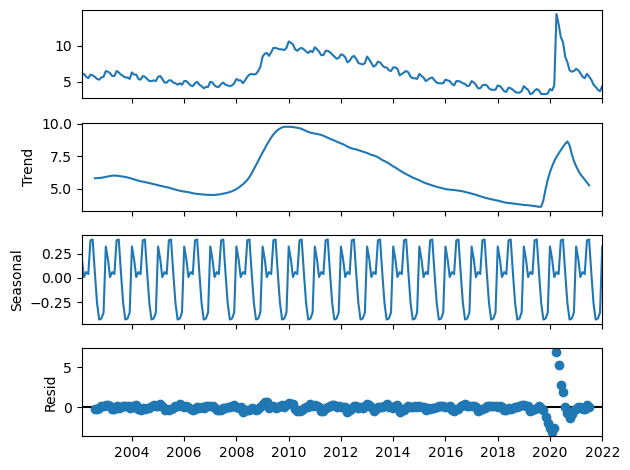

In [23]:
decomp_unemp = seasonal_decompose(unemp)
decomp_unemp.plot()

In [30]:
wn = np.random.normal(loc = data.spy_price.mean(), scale = data.spy_price.std(), size = len(data))

In [32]:
data['wn'] = wn
data.describe()

,spy_price,spy_vol,wn
count,7304.000000,7.304000e+03,7304.000000
mean,130.777536,8.649372e+07,129.929248
std,92.586625,9.495159e+07,92.277753
min,26.403795,5.200000e+03,-174.542072
25%,73.647396,1.066628e+07,67.861762
50%,95.041447,6.134810e+07,130.593973
75%,174.074555,1.212696e+08,191.031565
max,477.480011,8.710263e+08,486.827992


<Axes: xlabel='Date'>

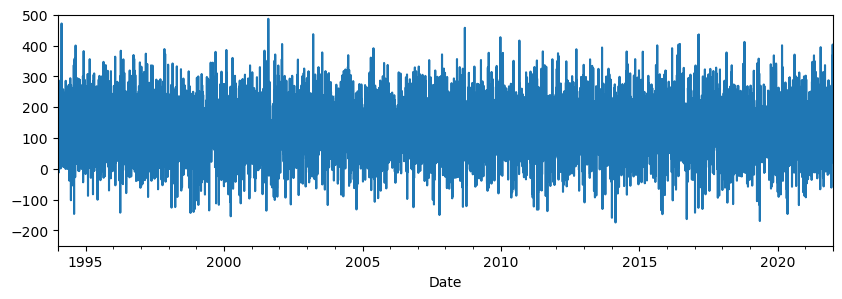

In [34]:
data.wn.plot(figsize = (10,3), ylim = (-250,500))

In [36]:
wn_rw = np.random.normal(loc = 0, scale = .05, size = len(data))
rw = np.zeros(len(data))
data['rw'] = rw
data['wn_rw'] = wn_rw

In [38]:
data.head(3)

,spy_price,spy_vol,wn,rw,wn_rw
Date,,,,,
1994-01-03,27.784529,960900.0,135.430766,0.0,-0.048681
1994-01-04,27.896648,164300.0,53.646068,0.0,0.023873
1994-01-05,27.952698,710900.0,106.140649,0.0,0.001271


In [40]:
data.rw.iloc[0] = 25

for i in range(1, len(data)):
    data.rw.iloc[i] = data.rw.iloc[i-1] + data.wn_rw.iloc[i]

data.head(3)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



,spy_price,spy_vol,wn,rw,wn_rw
Date,,,,,
1994-01-03,27.784529,960900.0,135.430766,25.000000,-0.048681
1994-01-04,27.896648,164300.0,53.646068,25.023873,0.023873
1994-01-05,27.952698,710900.0,106.140649,25.025144,0.001271


<Axes: xlabel='Date'>

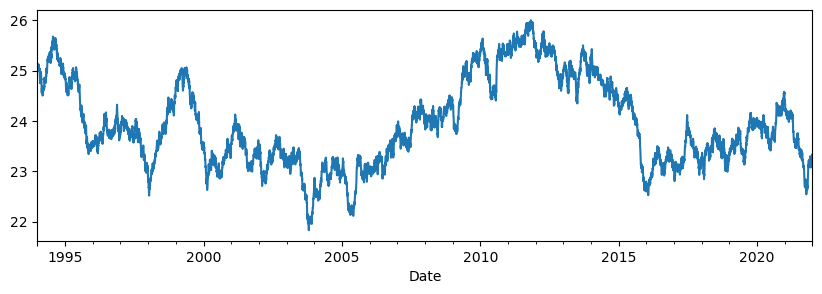

In [42]:
data.rw.plot(figsize = (10,3))